In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [49]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
searches = {
    # 'plan': f'{data_dir}/user_data/*exp4*/*r0*t0plan*.json',
    'shortcut': f'{data_dir}/user_data/*exp4*/*shortcut*.json',
}

valid_files = data_loading.get_valid_files(searches)

shortcut: 28/36 valid files


In [50]:
valid_files

['/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=493121589_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=3372424394_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=2764371760_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=4233470130_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=3867046102_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=1012357475_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=756885089_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_use

In [82]:
import glob

valid_files = glob.glob("data_deta*/*.json")
len(valid_files), valid_files

(0, [])

In [79]:
import json
def read_dicts_from_file(filename='data.json'):
    dictionaries = []
    with open(filename, 'r') as f:
        for line in f:
            # Parse each line as a JSON object (dictionary) and append it to the list
            dictionaries.append(json.loads(line.strip()))
    return dictionaries

file = valid_files[1]
data_dicts = read_dicts_from_file(file)
file, len(data_dicts)

('data/user=2121415607_name=exp_debug=2.json', 92)

In [80]:
keys=set()
for datum in data_dicts:
    try:
        maze = datum['metadata']['maze']
    except:
        continue
    # if 'practice' in maze: continue
    r = datum['metadata']['block_metadata'].get('reversal', None)
    image_seen_time_str = datum['data']['image_seen_time']
    image_seen_time = datetime.strptime(image_seen_time_str, '%Y-%m-%dT%H:%M:%S.%fZ')
    formatted_time = image_seen_time.strftime('%H:%M:%S')

    user_id = datum['user_data']['user_id']
    idx = datum['stage_idx']
    key = f"{idx} {maze}. rev={r}. eval={datum['metadata']['eval']}"
    if not key in keys:
        keys.add(key)
        print('-'*10)
        print(key)
        print(formatted_time)
        # print(len(keys))

----------
2 big_practice_maze. rev=None. eval=False
20:38:29
----------
3 big_practice_maze. rev=None. eval=False
20:38:34
----------
8 big_m4_maze_long_eval_same_blind. rev=[False, False]. eval=True
20:38:42
----------
9 big_m4_maze_long_eval_same_blind. rev=[False, False]. eval=True
20:38:46
----------
11 big_m4_maze_long_blind. rev=[False, True]. eval=False
20:38:51
----------
12 big_m4_maze_long_blind. rev=[False, True]. eval=False
20:38:56
----------
14 big_m4_maze_long_eval_diff. rev=[False, True]. eval=True
20:38:57
----------
15 big_m4_maze_long_eval_diff. rev=[False, True]. eval=True
20:39:06
----------
18 big_m4_maze_short_eval_same_blind. rev=[True, True]. eval=True
20:39:44
----------
19 big_m4_maze_short_eval_same_blind. rev=[True, True]. eval=True
20:39:49
----------
21 big_m4_maze_long_blind. rev=[True, True]. eval=False
20:39:58
----------
22 big_m4_maze_long_blind. rev=[True, True]. eval=False
20:40:03
----------
26 big_m4_maze_short_blind. rev=[False, False]. eval=Fa

In [74]:
[key for key in sorted(list(keys)) if 'short' in key]

['11 big_m4_maze_short_blind. rev=[False, True]. eval=False',
 '16 big_m4_maze_short_blind. rev=[True, False]. eval=False',
 '19 big_m4_maze_short_eval_diff. rev=[True, False]. eval=True',
 '20 big_m4_maze_short_eval_diff. rev=[True, False]. eval=True',
 '23 big_m4_maze_short_eval_same_blind. rev=[True, True]. eval=True',
 '41 big_m4_maze_short_blind. rev=[False, False]. eval=False',
 '43 big_m4_maze_short_eval_same_blind. rev=[False, False]. eval=True',
 '44 big_m4_maze_short_eval_diff. rev=[False, False]. eval=True']

In [75]:
[key for key in sorted(list(keys)) if 'long' in key]

['26 big_m4_maze_long_blind. rev=[False, True]. eval=False',
 '28 big_m4_maze_long_eval_same_blind. rev=[False, True]. eval=True',
 '29 big_m4_maze_long_eval_diff. rev=[False, True]. eval=True',
 '31 big_m4_maze_long_blind. rev=[False, False]. eval=False',
 '33 big_m4_maze_long_eval_same_blind. rev=[False, False]. eval=True',
 '34 big_m4_maze_long_eval_diff. rev=[False, False]. eval=True',
 '36 big_m4_maze_long_blind. rev=[True, True]. eval=False',
 '38 big_m4_maze_long_eval_same_blind. rev=[True, True]. eval=True',
 '39 big_m4_maze_long_eval_diff. rev=[True, True]. eval=True',
 '8 big_m4_maze_long_eval_same_blind. rev=[True, False]. eval=True',
 '9 big_m4_maze_long_eval_same_blind. rev=[True, False]. eval=True']

In [41]:
"""
should be:
- big_practice_maze = 2
- {big_m4_maze_short_blind, big_m4_maze_short_eval_diff, big_m4_maze_short_eval_same_blind} = 3 x 4 = 12
- short + long: 12--> 24.
- should be 14.
"""

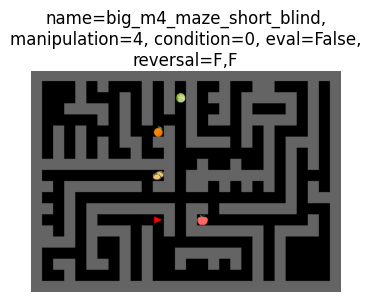

7
big_m4_maze_short_blind
name=big_m4_maze_short_blind, manipulation=4, condition=0, eval=False, reversal=F,F
00:02:59


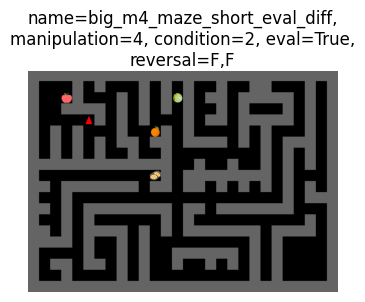

178
big_m4_maze_short_eval_diff
name=big_m4_maze_short_eval_diff, manipulation=4, condition=2, eval=True, reversal=F,F
00:06:38


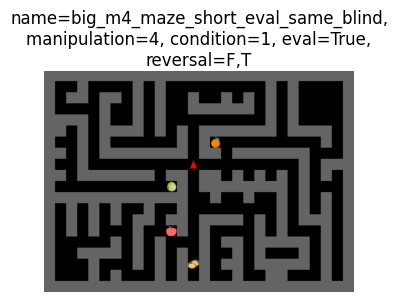

185
big_m4_maze_short_eval_same_blind
name=big_m4_maze_short_eval_same_blind, manipulation=4, condition=1, eval=True, reversal=F,T
00:06:59


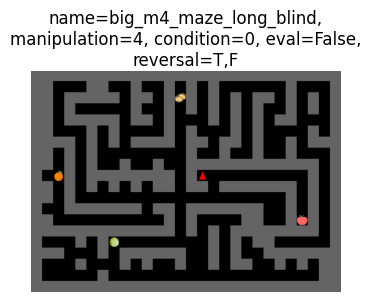

192
big_m4_maze_long_blind
name=big_m4_maze_long_blind, manipulation=4, condition=0, eval=False, reversal=T,F
00:07:11


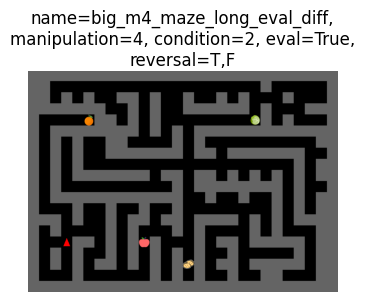

378
big_m4_maze_long_eval_diff
name=big_m4_maze_long_eval_diff, manipulation=4, condition=2, eval=True, reversal=T,F
00:10:41


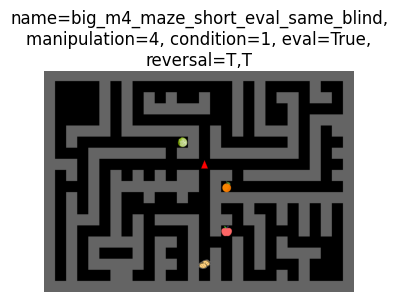

385
big_m4_maze_short_eval_same_blind
name=big_m4_maze_short_eval_same_blind, manipulation=4, condition=1, eval=True, reversal=T,T
00:10:57


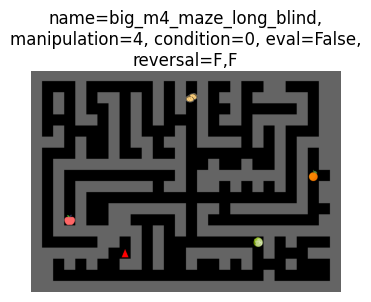

392
big_m4_maze_long_blind
name=big_m4_maze_long_blind, manipulation=4, condition=0, eval=False, reversal=F,F
00:11:30


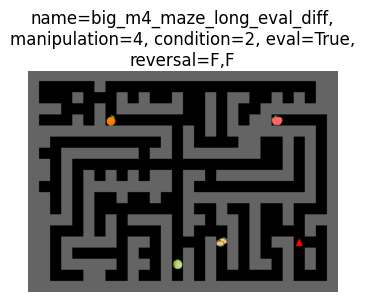

558
big_m4_maze_long_eval_diff
name=big_m4_maze_long_eval_diff, manipulation=4, condition=2, eval=True, reversal=F,F
00:16:33


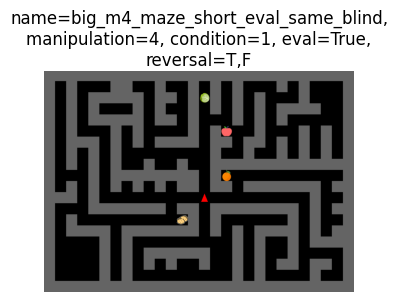

565
big_m4_maze_short_eval_same_blind
name=big_m4_maze_short_eval_same_blind, manipulation=4, condition=1, eval=True, reversal=T,F
00:17:17


In [42]:
from analysis.data_loading import dict_to_string, get_timestep, reversal_label
from analysis.housemaze_utils import housemaze_render_fn
import matplotlib.pyplot as plt
from datetime import datetime

def get_block_stage_description(datum):
    ####################
    # block information
    ####################
    block_metadata = datum['metadata']['block_metadata']
    # e.g. manipulation = 4
    block_manipulation = block_metadata.get('manipulation', -1)
    # e.g. desc = 'off-task object regular'
    block_desc = block_metadata.get('desc', 'unknown')

    ####################
    # stage information
    ####################
    reversal = datum['metadata']['block_metadata'].get('reversal', [False, False])
    return dict(
        # maze=datum['metadata'].get('maze'),
        name=datum['name'],
        manipulation=block_manipulation,
        condition=datum['metadata'].get('condition', 0),
        # block=block_desc,
        # episode_idx=datum['metadata']['episode_idx'],
        eval=datum['metadata']['eval'],
        reversal=reversal_label(reversal),
    )
# let's just print out the first few time-step to see what they look like
keys = set()
# nidx = 2
nidx = len(data_dicts)
for idx in range(nidx):
    datum = data_dicts[idx]
    if 'finished' in datum.keys(): continue
    if not 'image_seen_time' in datum['data']: continue
    
    # get the information describing block x stage pairs. you can edit this function if you want
    info = get_block_stage_description(datum)
    title = dict_to_string(info)
    if 'practice' in title: continue

    # if not('diff' in datum['name'] or 'same' in datum['name']): continue

    if not title in keys:
        print("="*100)
        keys.add(title)
    
        timestep = get_timestep(datum, example_web_timestep)
        image = housemaze_render_fn(timestep.state)
        # action_taken: int = datum['action_idx']
    
        fig, ax = plt.subplots(1, 1, figsize=(4,4))
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(title, wrap=True)
        plt.show()
    
        print(idx)
        print(datum['name'])
        image_seen_time_str = datum['data']['image_seen_time']
        image_seen_time = datetime.strptime(image_seen_time_str, '%Y-%m-%dT%H:%M:%S.%fZ')
        formatted_time = image_seen_time.strftime('%H:%M:%S')
        print(title)
        print(formatted_time)